# Melbourne Housing Market Analysis: Property Pricing, Features, and Regional Trends

## Step 1: Data Loading and Initial Overview

In this step, we import the dataset and get an initial understanding of its structure, size, and data types before any cleaning begins.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('melb_data.csv')
print("Shape of dataset:", df.shape)

Shape of dataset: (13580, 21)


In [2]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  str    
 17  Lattitude      13580 non-null  float64
 18  Longtitude     13

In [4]:
df.describe()
df.describe(include='str')

,Suburb,Address,Type,Method,SellerG,Date,CouncilArea,Regionname
count,13580,13580,13580,13580,13580,13580,12211,13580
unique,314,13378,3,5,268,58,33,8
top,Reservoir,5 Charles St,h,S,Nelson,27/05/2017,Moreland,Southern Metropolitan
freq,359,3,9449,9022,1565,473,1163,4695


## Step 2: Data Pre-processing

In this step, we handle missing values, convert data types, and create derived columns to prepare the dataset for analysis.

In [5]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
print(df['Date'].dtype)
print(df['Date'].min(), "to", df['Date'].max())

datetime64[us]
2016-01-28 00:00:00 to 2017-09-23 00:00:00


In [6]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})
print(missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False))

              Missing Count  Missing %
BuildingArea           6450  47.496318
YearBuilt              5375  39.580265
CouncilArea            1369  10.081001
Car                      62   0.456554


In [7]:
df['Car'] = df['Car'].fillna(df['Car'].median())
df['CouncilArea'] = df['CouncilArea'].fillna('Unknown')
df['YearBuilt_Missing'] = df['YearBuilt'].isnull().astype(int)
df['YearBuilt'] = df.groupby('Suburb')['YearBuilt'].transform(lambda x: x.fillna(x.median()))
df['YearBuilt'] = df['YearBuilt'].fillna(df['YearBuilt'].median())
df['BuildingArea_Missing'] = df['BuildingArea'].isnull().astype(int)
df['BuildingArea'] = df.groupby('Suburb')['BuildingArea'].transform(lambda x: x.fillna(x.median()))
df['BuildingArea'] = df['BuildingArea'].fillna(df['BuildingArea'].median())

In [8]:
print(df.isnull().sum().sum(), "total missing values remaining")

0 total missing values remaining


### Handling Missing Data
`Car` and `CouncilArea` had minimal missingness and were imputed with the median and 'Unknown' respectively. `YearBuilt` and `BuildingArea` had substantial missingness (~40–47%). Rather than dropping these columns or rows — which would remove a large portion of the dataset — missing values were imputed using the median value within each suburb, since property characteristics vary meaningfully by location. Flag columns (`YearBuilt_Missing`, `BuildingArea_Missing`) were created so this imputation remains transparent and can be accounted for in later analysis.

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


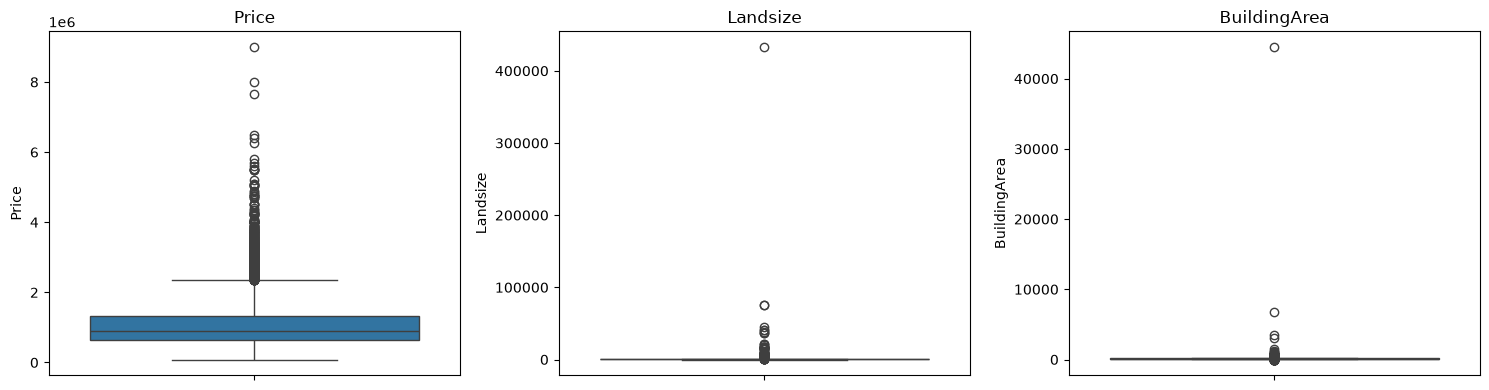

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df['Price'], ax=axes[0])
axes[0].set_title('Price')
sns.boxplot(y=df['Landsize'], ax=axes[1])
axes[1].set_title('Landsize')
sns.boxplot(y=df['BuildingArea'], ax=axes[2])
axes[2].set_title('BuildingArea')
plt.tight_layout()
plt.show()

In [11]:
print(df['Landsize'].describe())
print()
print("Properties with Landsize = 0:", (df['Landsize'] == 0).sum())

count     13580.000000
mean        558.416127
std        3990.669241
min           0.000000
25%         177.000000
50%         440.000000
75%         651.000000
max      433014.000000
Name: Landsize, dtype: float64

Properties with Landsize = 0: 1939


In [12]:
df['Price_per_sqm'] = df['Price'] / df['BuildingArea'].replace(0, np.nan)
df['Property_Age'] = df['Date'].dt.year - df['YearBuilt']
df['Sale_Year'] = df['Date'].dt.year
df['Sale_Month'] = df['Date'].dt.month
df[['Price_per_sqm', 'Property_Age', 'Sale_Year', 'Sale_Month']].describe()

,Price_per_sqm,Property_Age,Sale_Year,Sale_Month
count,1.356300e+04,13580.000000,13580.000000,13580.000000
mean,1.012588e+04,52.261561,2016.533432,7.052283
std,4.436163e+04,31.619368,0.498899,2.536034
min,3.043918e+01,-2.000000,2016.000000,1.000000
25%,5.479452e+03,35.500000,2016.000000,5.000000
50%,7.373418e+03,47.000000,2017.000000,7.000000
75%,9.697623e+03,66.000000,2017.000000,9.000000
max,3.812000e+06,821.000000,2017.000000,12.000000


In [13]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[column].clip(lower=lower, upper=upper)
for col in ['Price', 'Landsize', 'BuildingArea']:
    df[col] = cap_outliers_iqr(df, col)
print(df[['Price', 'Landsize', 'BuildingArea']].describe())

              Price      Landsize  BuildingArea
count  1.358000e+04  13580.000000  13580.000000
mean   1.044248e+06    440.496760    133.764634
std    5.271031e+05    323.146283     48.233158
min    8.500000e+04      0.000000     16.250000
25%    6.500000e+05    177.000000    102.500000
50%    9.030000e+05    440.000000    126.500000
75%    1.330000e+06    651.000000    160.000000
max    2.350000e+06   1362.000000    246.250000


In [14]:
print("Rows with negative Property_Age:", (df['Property_Age'] < 0).sum())
df.loc[df['Property_Age'] < 0, 'Property_Age'] = np.nan
df['Property_Age'] = df['Property_Age'].fillna(df['Property_Age'].median())

Rows with negative Property_Age: 6


In [15]:
df['Price_per_sqm'] = df['Price'] / df['BuildingArea'].replace(0, np.nan)
df['Price_per_sqm'] = df['Price_per_sqm'].fillna(df['Price_per_sqm'].median())
print(df['Price_per_sqm'].describe())

count     13580.000000
mean       8435.455464
std        6431.049679
min         845.161290
25%        5530.805846
50%        7455.748747
75%        9605.975307
max      144615.384615
Name: Price_per_sqm, dtype: float64


### Outlier Handling
Extreme outliers in `Price`, `Landsize`, and `BuildingArea` were identified using the IQR method and capped at the upper/lower bounds rather than removed, to preserve sample size while preventing distortion of averages and visualizations. Six rows had a negative `Property_Age` (sale date before the recorded build year), indicating a data entry inconsistency; these were treated as missing and imputed with the median age.